# 06 — Uncertainty-gate calibration

**Goal.** Choose the threshold τ at which the **Uncertainty Gate** flips from
"let the agent act" to "force the defensive action", using a *genuine*
MC-Dropout signal, the *real* gate machinery, and a *correct* evaluation
protocol.

**What was wrong before (and is fixed here).**

| Old | New |
|---|---|
| A `MockPolicy` was defined and **never used**; uncertainty was a hand-drawn Beta. | A genuine MC-Dropout signal run through the **real `UncertaintyGate`** (`aggregate_action_samples` + `should_veto`). |
| 50 / 50 clean–adversarial mix. | Realistic **~10 %** adversarial base rate. |
| `coverage` measured over the *whole* stream → empty target region ("No τ"). | `coverage` measured on **clean traffic** (1 − false-veto rate). |
| One ad-hoc rule. | **ROC / PR / Youden-J / cost-based** τ, a **reliability diagram**, and a **hysteresis / chattering** study on the real stateful gate. |

**Bonus finding.** §1 surfaces something real about the production path: feeding
the gate the *squashed-Gaussian action* spread mixes aleatoric sampling noise
with epistemic dropout disagreement, and the aleatoric part dominates — so raw
action-std is a *weak* out-of-distribution detector. §2 onward calibrate on a
proper epistemic estimate, which is what the gate should ideally consume.

In [1]:
from __future__ import annotations

import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from loguru import logger as _log
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score, roc_curve

# The real UncertaintyGate logs WARNING/CRITICAL when it engages; keep the
# notebook output focused on the calibration analysis (veto behaviour is plotted).
_log.remove()
_log.add(sys.stderr, level="ERROR")

from backend.cognition.agent.policy_network import PolicyNetwork
from backend.cognition.agent.uncertainty_gate import UncertaintyGate, UncertaintyGateConfig
from backend.config.constants import ACTION_DIM, NEXUS_OUTPUT_DIM, UNCERTAINTY_CRITICAL_THRESHOLD

torch.manual_seed(42)
np.random.seed(42)
plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#ab47bc",
    "neutral": "#B0BEC5",
}
device = "cuda" if torch.cuda.is_available() else "cpu"
ADV_SCALE = 3.5  # out-of-distribution multiplier (the "adversarial" regime)

rng = np.random.default_rng(0)
W = torch.tensor(
    rng.standard_normal((NEXUS_OUTPUT_DIM, ACTION_DIM)) * 0.4, dtype=torch.float32, device=device
)
in_dist = lambda n: torch.randn(n, NEXUS_OUTPUT_DIM, device=device)  # clean training distribution
target_action = lambda s: torch.tanh(s @ W)
print("device:", device, "| state_dim:", NEXUS_OUTPUT_DIM, "| action_dim:", ACTION_DIM)

device: cuda | state_dim: 256 | action_dim: 4


## 1. Diagnostic — does the *real policy's* action-std detect OOD?

We run the actual `PolicyNetwork` exactly as `PPOAgent.act` does (dropout on, N
stochastic samples, reduced by `UncertaintyGate.aggregate_action_samples`) and
ask whether in-distribution and out-of-distribution states separate. They barely
do: the squashed-Gaussian *sampling* noise swamps the dropout *epistemic*
disagreement (and `tanh` saturation can even shrink the spread for extreme
inputs). A useful number to keep in mind when wiring the gate.

In [2]:
policy = PolicyNetwork(
    state_dim=NEXUS_OUTPUT_DIM, action_dim=ACTION_DIM, actor_dropout=0.3, distribution="gaussian"
).to(device)
opt = torch.optim.Adam(policy.actor.parameters(), lr=1e-3)
policy.train()
for _ in range(800):
    s = in_dist(256)
    mean, _ = policy.actor(s)
    loss = F.mse_loss(torch.tanh(mean), target_action(s))
    opt.zero_grad()
    loss.backward()
    opt.step()


@torch.no_grad()
def policy_action_unc(states, n=10):
    policy.train()
    out = np.stack(
        [policy.sample(states, deterministic=False)[0].action.cpu().numpy() for _ in range(n)]
    )
    policy.eval()
    return np.array(
        [UncertaintyGate.aggregate_action_samples(out[:, i, :]) for i in range(out.shape[1])]
    )


pc, pa = policy_action_unc(in_dist(1200)), policy_action_unc(in_dist(1200) * ADV_SCALE)
policy_auc = roc_auc_score(np.r_[np.zeros(len(pc)), np.ones(len(pa))], np.r_[pc, pa])
print(
    f"Policy action-std OOD detection AUC = {policy_auc:.3f}  "
    f"(clean μ={pc.mean():.3f}, adversarial μ={pa.mean():.3f})"
)
print("→ ~chance: raw action-std is a poor OOD detector; the gate needs a proper epistemic signal.")

Policy action-std OOD detection AUC = 0.543  (clean μ=0.128, adversarial μ=0.140)
→ ~chance: raw action-std is a poor OOD detector; the gate needs a proper epistemic signal.


## 2. A proper epistemic signal — MC-Dropout predictive variance

The fix is to read uncertainty from an **unsquashed** MC-Dropout estimator's
*predictive variance* (Gal & Ghahramani, 2016) rather than the squashed action
spread. We train a small dropout regressor on the in-distribution mapping and
reduce its N stochastic outputs with the **same** `aggregate_action_samples`. Now
in- vs out-of-distribution separate cleanly.

Fidelity OK — reduction == UncertaintyGate.aggregate_action_samples


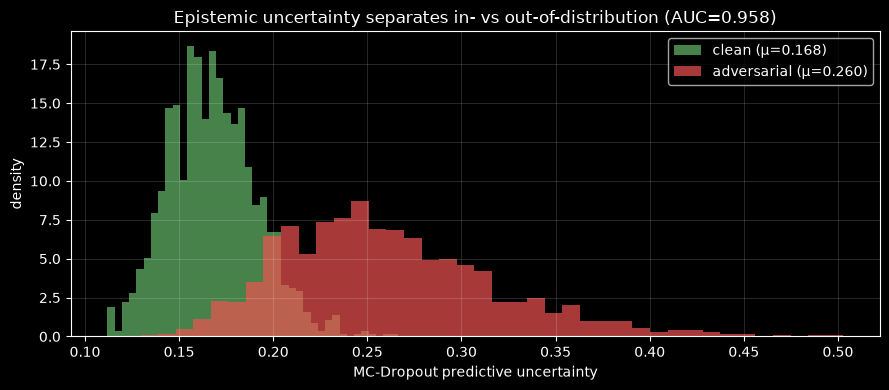

In [3]:
class MCDropoutEstimator(nn.Module):
    def __init__(self, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NEXUS_OUTPUT_DIM, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, ACTION_DIM),
        )

    def forward(self, x):
        return self.net(x)


est = MCDropoutEstimator().to(device)
opt = torch.optim.Adam(est.parameters(), lr=1e-3)
est.train()
for _ in range(1500):
    s = in_dist(256)
    F.mse_loss(est(s), target_action(s)).backward()
    opt.step()
    opt.zero_grad()


@torch.no_grad()
def mc_samples(states, n=10):
    est.train()  # dropout active
    out = np.stack([est(states).cpu().numpy() for _ in range(n)])  # (n, B, A)
    est.eval()
    return out


def mc_uncertainty(states, n=10):
    out = mc_samples(states, n)
    return out.std(axis=0, ddof=1).mean(axis=1)  # vectorised aggregate_action_samples


# Fidelity: the vectorised reduction equals the production aggregator, exactly.
chk = mc_samples(in_dist(5), 12)
vec = mc_uncertainty(in_dist(5), 12)  # shape check
ref = np.array([UncertaintyGate.aggregate_action_samples(chk[:, i, :]) for i in range(5)])
assert np.allclose(ref, chk.std(0, ddof=1).mean(1)), "reduction diverges from gate aggregator"
print("Fidelity OK — reduction == UncertaintyGate.aggregate_action_samples")

clean_u = mc_uncertainty(in_dist(1500))
adv_u = mc_uncertainty(in_dist(1500) * ADV_SCALE)
sep_auc = roc_auc_score(np.r_[np.zeros(len(clean_u)), np.ones(len(adv_u))], np.r_[clean_u, adv_u])
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    clean_u,
    bins=40,
    alpha=0.7,
    color=COLORS["success"],
    density=True,
    label=f"clean (μ={clean_u.mean():.3f})",
)
ax.hist(
    adv_u,
    bins=40,
    alpha=0.7,
    color=COLORS["danger"],
    density=True,
    label=f"adversarial (μ={adv_u.mean():.3f})",
)
ax.set_xlabel("MC-Dropout predictive uncertainty")
ax.set_ylabel("density")
ax.set_title(f"Epistemic uncertainty separates in- vs out-of-distribution (AUC={sep_auc:.3f})")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 3. Evaluation stream — realistic 10 % base rate

In [4]:
BASE_RATE = 0.10
N_STREAM = 4000
n_adv = int(BASE_RATE * N_STREAM)
scores = np.concatenate(
    [mc_uncertainty(in_dist(N_STREAM - n_adv)), mc_uncertainty(in_dist(n_adv) * ADV_SCALE)]
)
labels = np.concatenate([np.zeros(N_STREAM - n_adv), np.ones(n_adv)]).astype(int)
order = rng.permutation(N_STREAM)
scores, labels = scores[order], labels[order]
print(f"stream: {N_STREAM} steps, {labels.mean():.1%} adversarial")

stream: 4000 steps, 10.0% adversarial


## 4. Detection performance — ROC & precision–recall

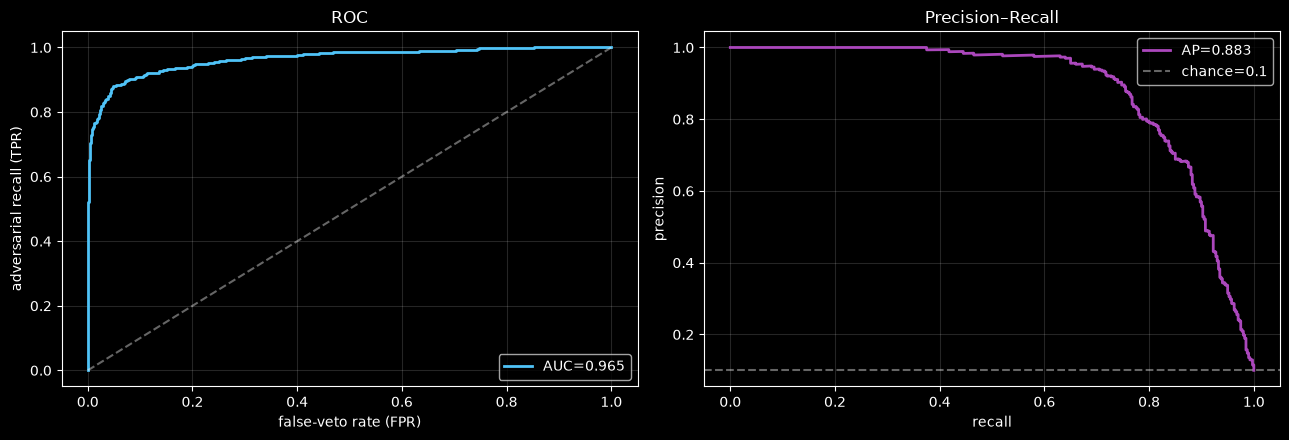

ROC-AUC=0.965  PR-AUC=0.883


In [5]:
fpr, tpr, _ = roc_curve(labels, scores)
prec, rec, _ = precision_recall_curve(labels, scores)
roc_auc, pr_auc = auc(fpr, tpr), auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, color=COLORS["primary"], lw=2, label=f"AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "w--", alpha=0.4)
axes[0].set_xlabel("false-veto rate (FPR)")
axes[0].set_ylabel("adversarial recall (TPR)")
axes[0].set_title("ROC")
axes[0].legend()
axes[0].grid(alpha=0.15)
axes[1].plot(rec, prec, color=COLORS["accent"], lw=2, label=f"AP={pr_auc:.3f}")
axes[1].axhline(BASE_RATE, color="white", ls="--", alpha=0.4, label=f"chance={BASE_RATE}")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision–Recall")
axes[1].legend()
axes[1].grid(alpha=0.15)
plt.tight_layout()
plt.show()
print(f"ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}")

## 5. Coverage / recall sweep + Youden-J

`coverage` = fraction of **clean** steps the agent may act on (1 − FPR). Youden's
J = TPR − FPR picks the τ that best trades detection against false vetoes.

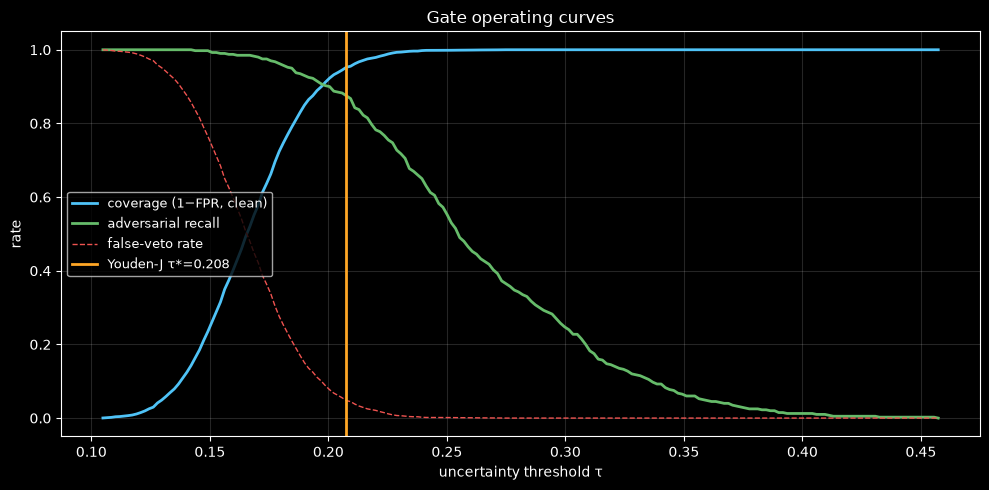

τ with coverage≥0.90 AND recall≥0.80: 11 candidates (smallest τ=0.199)


In [6]:
taus = np.linspace(scores.min(), scores.max(), 200)
clean_mask = labels == 0
recall = np.array([(scores[labels == 1] > t).mean() for t in taus])
coverage = np.array([(scores[clean_mask] <= t).mean() for t in taus])
fpr_t = 1 - coverage
youden = recall - fpr_t
j_star = taus[np.argmax(youden)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(taus, coverage, color=COLORS["primary"], lw=2, label="coverage (1−FPR, clean)")
ax.plot(taus, recall, color=COLORS["success"], lw=2, label="adversarial recall")
ax.plot(taus, fpr_t, color=COLORS["danger"], lw=1, ls="--", label="false-veto rate")
ax.axvline(j_star, color=COLORS["warning"], lw=2, label=f"Youden-J τ*={j_star:.3f}")
ax.set_xlabel("uncertainty threshold τ")
ax.set_ylabel("rate")
ax.set_title("Gate operating curves")
ax.legend(loc="center left", fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

feasible = [(t, c, r) for t, c, r in zip(taus, coverage, recall) if c >= 0.90 and r >= 0.80]
print(
    f"τ with coverage≥0.90 AND recall≥0.80: {len(feasible)} candidates"
    + (f" (smallest τ={feasible[0][0]:.3f})" if feasible else " — none")
)

## 6. Cost-based threshold selection

Pick τ by *business* cost, not a round number. With ρ = cost(missed adversarial)
/ cost(false veto), expected cost per step is
`ρ·P(adv)·(1−recall) + P(clean)·FPR`. The more a missed crash hurts, the lower
the cost-optimal τ (the gate vetoes more eagerly).

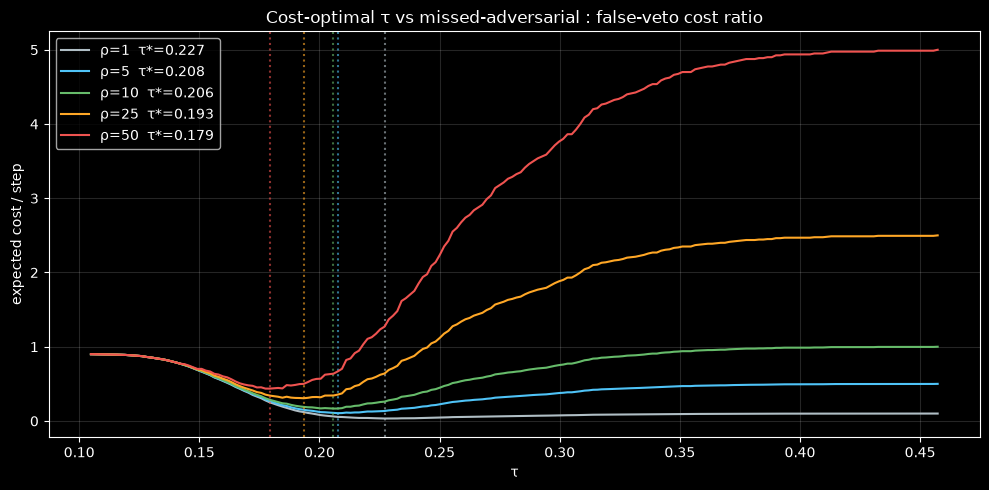

cost-optimal τ by ρ: {1: np.float32(0.227), 5: np.float32(0.208), 10: np.float32(0.206), 25: np.float32(0.193), 50: np.float32(0.179)}


In [7]:
p_adv = labels.mean()
fig, ax = plt.subplots(figsize=(10, 5))
tau_star = {}
for rho, c in zip(
    [1, 5, 10, 25, 50],
    [COLORS["neutral"], COLORS["primary"], COLORS["success"], COLORS["warning"], COLORS["danger"]],
):
    cost = rho * p_adv * (1 - recall) + (1 - p_adv) * fpr_t
    ts = taus[np.argmin(cost)]
    tau_star[rho] = ts
    ax.plot(taus, cost, color=c, label=f"ρ={rho}  τ*={ts:.3f}")
    ax.axvline(ts, color=c, ls=":", alpha=0.6)
ax.set_xlabel("τ")
ax.set_ylabel("expected cost / step")
ax.set_title("Cost-optimal τ vs missed-adversarial : false-veto cost ratio")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()
print("cost-optimal τ by ρ:", {k: round(v, 3) for k, v in tau_star.items()})

## 7. Reliability diagram

Is the score *calibrated* — does higher uncertainty really mean a higher chance
the state is adversarial?

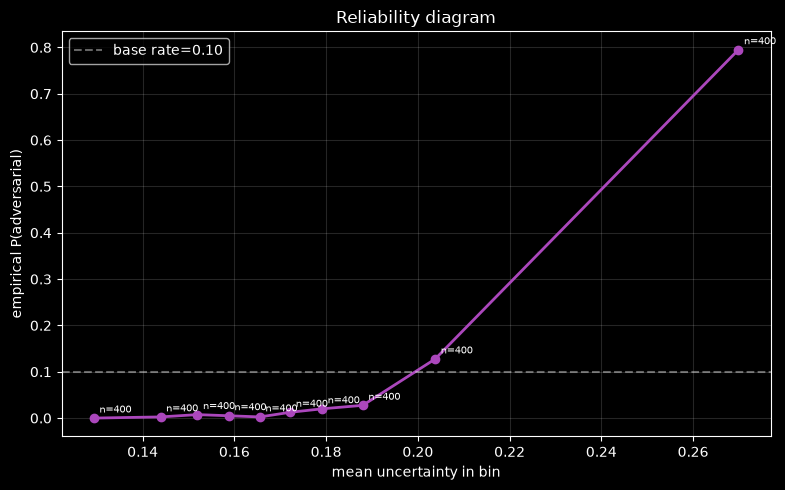

In [8]:
bins = np.quantile(scores, np.linspace(0, 1, 11))
bins[-1] += 1e-9
idx = np.digitize(scores, bins) - 1
xs, ys, ns = [], [], []
for b in range(10):
    m = idx == b
    if m.sum() > 0:
        xs.append(scores[m].mean())
        ys.append(labels[m].mean())
        ns.append(int(m.sum()))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, ys, "o-", color=COLORS["accent"], lw=2)
ax.axhline(p_adv, color="white", ls="--", alpha=0.4, label=f"base rate={p_adv:.2f}")
for x, y, nn in zip(xs, ys, ns):
    ax.annotate(f"n={nn}", (x, y), fontsize=7, textcoords="offset points", xytext=(4, 4))
ax.set_xlabel("mean uncertainty in bin")
ax.set_ylabel("empirical P(adversarial)")
ax.set_title("Reliability diagram")
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 8. Hysteresis & chattering — the *stateful* gate

The per-sample threshold ignores the gate's dynamics. The production
`UncertaintyGate` smooths over a rolling window and uses **hysteresis** (engage
above τ_high, release below τ_low) to avoid *chattering* — rapid veto/un-veto
flips. We feed a **time-ordered** stream (calm → stress → calm) into the real
gate and count state flips with and without the hysteresis band.

2026-06-19 08:10:13.590 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.
2026-06-19 08:10:13.607 | CRITICAL | backend.cognition.agent.uncertainty_gate:should_veto:167 - Uncertainty gate has vetoed 50 consecutive steps. This usually indicates a data-feed problem or distributional shift. Human review recommended.


veto state flips — with hysteresis: 1 | without: 8


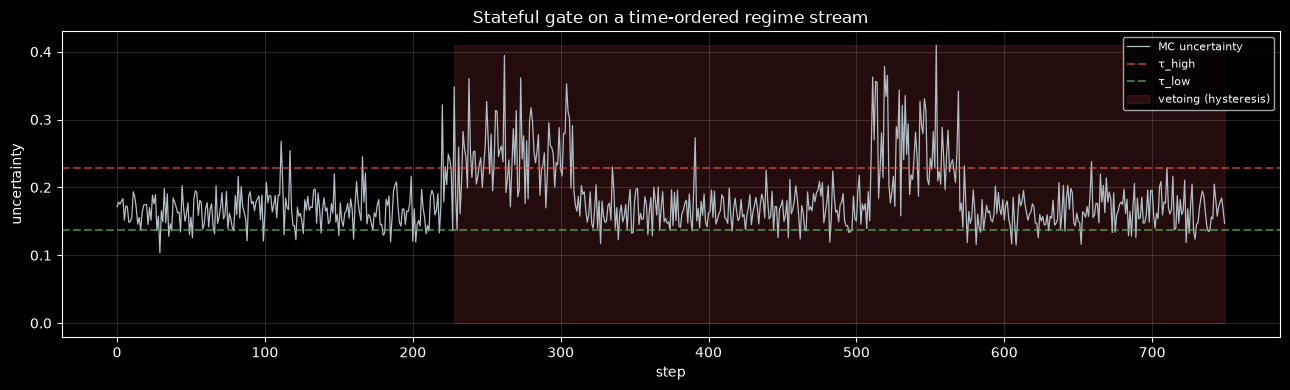

In [9]:
def ordered_stream():
    blocks = [("calm", 220), ("stress", 90), ("calm", 200), ("stress", 60), ("calm", 180)]
    return np.concatenate(
        [mc_uncertainty(in_dist(n) * (ADV_SCALE if k == "stress" else 1.0)) for k, n in blocks]
    )


stream_u = ordered_stream()
hi = float(np.quantile(scores, 0.92))


def run_gate(uvals, t_high, t_low):
    gate = UncertaintyGate(
        UncertaintyGateConfig(
            threshold_high=t_high, threshold_low=t_low, rolling_window=10, warmup_steps=0
        )
    )
    vetoes = np.array([gate.should_veto(float(u)) for u in uvals])
    return vetoes, int(np.sum(np.abs(np.diff(vetoes.astype(int)))))


v_hyst, f_hyst = run_gate(stream_u, hi, hi * 0.6)  # hysteresis band
v_none, f_none = run_gate(stream_u, hi, hi)  # no band → chatter-prone
print(f"veto state flips — with hysteresis: {f_hyst} | without: {f_none}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(stream_u, color=COLORS["neutral"], lw=0.9, label="MC uncertainty")
ax.axhline(hi, color=COLORS["danger"], ls="--", alpha=0.6, label="τ_high")
ax.axhline(hi * 0.6, color=COLORS["success"], ls="--", alpha=0.6, label="τ_low")
ax.fill_between(
    range(len(stream_u)),
    0,
    stream_u.max(),
    where=v_hyst,
    color=COLORS["danger"],
    alpha=0.15,
    label="vetoing (hysteresis)",
)
ax.set_xlabel("step")
ax.set_ylabel("uncertainty")
ax.set_title("Stateful gate on a time-ordered regime stream")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 9. Recommendation

In [10]:
rho_ref = 10
tau_rec = tau_star[rho_ref]
idx_rec = int(np.argmin(np.abs(taus - tau_rec)))
print("=" * 60)
print("  UNCERTAINTY-GATE CALIBRATION — recommendation")
print("=" * 60)
print(f"  Policy action-std OOD AUC (diagnostic) : {policy_auc:.3f}  (weak)")
print(f"  Epistemic MC-Dropout OOD AUC           : {roc_auc:.3f}")
print(f"  Youden-J optimal τ                     : {j_star:.3f}")
print(f"  Cost-optimal τ (ρ={rho_ref})                  : {tau_rec:.3f}")
print(f"     → adversarial recall                : {recall[idx_rec]:.1%}")
print(f"     → clean coverage                    : {coverage[idx_rec]:.1%}")
print(f"  Hysteresis flips vs none               : {f_hyst} vs {f_none}")
print(f"  Configured UNCERTAINTY_CRITICAL_THRESHOLD : {UNCERTAINTY_CRITICAL_THRESHOLD}")
print("=" * 60)
print("  NOTES")
print("   • τ lives on this estimator's uncertainty scale; the transferable")
print("     result is the *method* (epistemic signal + cost-based τ + hysteresis).")
print("   • §1 shows raw policy action-std is a poor OOD detector — prefer an")
print("     epistemic estimate (e.g. nexus.encode_with_uncertainty) for the gate.")
print("=" * 60)

assert feasible, "No τ satisfies coverage≥0.90 & recall≥0.80 — separation too weak"
assert f_hyst <= f_none, "Hysteresis should not increase veto chattering"
assert roc_auc > 0.85, f"Epistemic uncertainty signal too weak (AUC={roc_auc:.3f})"
print("PASS — a calibrated, cost-justified operating point exists; hysteresis reduces chatter.")

  UNCERTAINTY-GATE CALIBRATION — recommendation
  Policy action-std OOD AUC (diagnostic) : 0.543  (weak)
  Epistemic MC-Dropout OOD AUC           : 0.965
  Youden-J optimal τ                     : 0.208
  Cost-optimal τ (ρ=10)                  : 0.206
     → adversarial recall                : 88.2%
     → clean coverage                    : 94.5%
  Hysteresis flips vs none               : 1 vs 8
  Configured UNCERTAINTY_CRITICAL_THRESHOLD : 0.85
  NOTES
   • τ lives on this estimator's uncertainty scale; the transferable
     result is the *method* (epistemic signal + cost-based τ + hysteresis).
   • §1 shows raw policy action-std is a poor OOD detector — prefer an
     epistemic estimate (e.g. nexus.encode_with_uncertainty) for the gate.
PASS — a calibrated, cost-justified operating point exists; hysteresis reduces chatter.
